# DATA VISUALIZATION

## Importation des différentes librairies utilisées

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

## Création d'un Dataset fictif pour tester les fonctions de visualisation

Simulation d'un data set pour tester les différentes fonctions de visualisation

In [4]:
#import pandas as pd
#import numpy as np

# Liste des genres disponibles
final_genre_list = ['rock', 'rap', 'country', 'blues', 'metal', 'r&b', 'classical music', 'jazz', 'pop']

# Nombre de lignes à générer
num_rows = 5000

# Générer des genres aléatoires à partir de final_genre_list
np.random.seed(42)  # Pour avoir des résultats reproductibles
genres = np.random.choice(final_genre_list, num_rows)

# Générer des caractéristiques aléatoires pour chaque musique
bpm = np.random.randint(60, 180, num_rows)  # BPM entre 60 et 180
tempo = bpm + np.random.randint(-10, 10, num_rows)  # Tempo légèrement corrélé avec BPM

key = np.random.choice(['C', 'D', 'E', 'F', 'G', 'A', 'B'], num_rows)  # Clé musicale parmi ces notes
loudness = np.random.rand(num_rows) * 100  # Loudness entre 0 et 100
energy = loudness * 0.8 + np.random.rand(num_rows) * 20  # Energy corrélée à loudness
mode = np.random.choice([0, 1], num_rows)  # Mode : 0 pour mineur, 1 pour majeur
speechiness = np.random.rand(num_rows) * 100  # Speechiness entre 0 et 100
acousticness = np.random.rand(num_rows) * 100  # Acousticness entre 0 et 100
instrumentalness = np.random.rand(num_rows) * 100  # Instrumentalness entre 0 et 100
liveness = np.random.rand(num_rows) * 100  # Liveness entre 0 et 100
valence = np.random.rand(num_rows) * 100  # Valence entre 0 et 100
duration_ms = np.random.randint(180000, 300000, num_rows)  # Durée entre 3 et 5 minutes en millisecondes
time_signature = np.random.choice([3, 4], num_rows)  # Time signature : 3 ou 4 temps

# Créer le DataFrame
Dataset_Genres = pd.DataFrame({
    'genre': genres,
    'bpm': bpm,
    'tempo': tempo,
    'key': key,
    'loudness': loudness,
    'energy': energy,
    'mode': mode,
    'speechiness': speechiness,
    'acousticness': acousticness,
    'instrumentalness': instrumentalness,
    'liveness': liveness,
    'valence': valence,
    'duration_ms': duration_ms,
    'time_signature': time_signature
})

# Afficher un extrait du DataFrame
print(Dataset_Genres.head())

             genre  bpm  tempo key   loudness     energy  mode  speechiness  \
0  classical music   96    100   A   0.958564  17.973858     1    95.754171   
1            blues   85     83   C  28.384615  25.513055     1    40.535203   
2             jazz  158    154   A  11.929958  18.142761     0    45.723041   
3            metal  157    156   D  10.280856  10.169173     0    70.160209   
4  classical music  158    160   E   7.748729  13.990888     1    52.424973   

   acousticness  instrumentalness   liveness    valence  duration_ms  \
0     51.971429         62.712230  51.594503  17.595874       262611   
1     25.266620         76.066694  56.457537  74.551326       216646   
2     99.867255         47.214485   8.413179  30.688777       183916   
3     26.696194         10.529261  36.521875  22.607108       213426   
4     23.068584         24.480501  15.621886  55.786918       237527   

   time_signature  
0               4  
1               3  
2               4  
3           

## Distribution du Genre

Vérification de l'équilibre dans la répartition des genres au sein de notre dataset.
Ici ça ne devrait pas poser problème étant donné que nous avons choisi nous même des playlists avec un nombre de titres assez similaire.

Pour ce faire, nous créons une nouvelle colonne binaire pour chaque genre musical. Par exemple, dans la colonne pop, la valeur d'une musique du genre pop est 1, mais celle d'une musique d'un autre genre est 0. Cela permet de manipuler de manipuler des colonnes numériques, donc pas catégorielles.

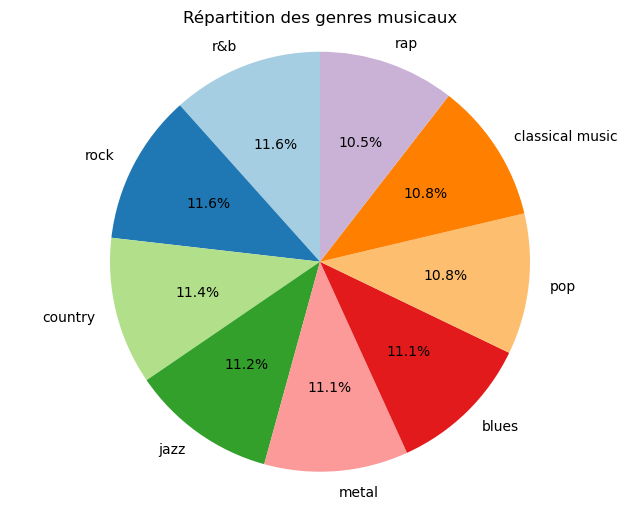

In [5]:

#import matplotlib.pyplot as plt

#final_genre_list = ['rock','rap','country','blues','metal','r&b','classical music','jazz','pop']

Dataset_Genres_bis = Dataset_Genres.copy()

def plot_genre_distribution(data, genre_list):
    # Compter le nombre d'occurrences de chaque genre dans le dataset
    genre_counts = data['genre'].value_counts()
    
    # Filtrer pour ne conserver que les genres dans genre_list
    genre_counts = genre_counts[genre_counts.index.isin(genre_list)]
    
    # Créer un camembert pour la répartition des genres
    plt.figure(figsize=(8, 6))
    plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title('Répartition des genres musicaux')
    plt.axis('equal')  # Pour un cercle parfait
    plt.show()

# Application à nos données
plot_genre_distribution(Dataset_Genres_bis, final_genre_list)

## Heat Map

<Figure size 1000x800 with 0 Axes>

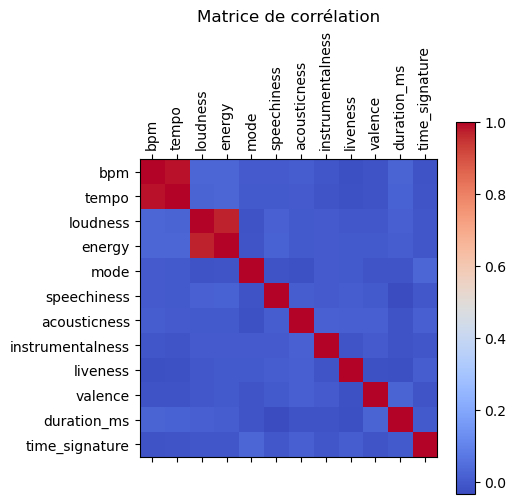

In [6]:
#import matplotlib.pyplot as plt
#import numpy as np

def plot_correlation_matrix(Dataset_Genres_bis):
    # Sélectionner uniquement les colonnes numériques du DataFrame
    Dataset_Genres_bis_numeric = Dataset_Genres_bis.select_dtypes(include=[float, int])

    # Calculer la matrice de corrélation
    corr_matrix = Dataset_Genres_bis_numeric.corr()

    # Créer la figure
    f = plt.figure(figsize=(10, 8))

    # Tracer la matrice de corrélation
    plt.matshow(corr_matrix, cmap='coolwarm')

    # Ajouter les ticks des axes
    plt.xticks(range(Dataset_Genres_bis_numeric.shape[1]), Dataset_Genres_bis_numeric.columns, rotation=90, fontsize=10)
    plt.yticks(range(Dataset_Genres_bis_numeric.shape[1]), Dataset_Genres_bis_numeric.columns, fontsize=10)

 #   # Ajouter les valeurs dans les cellules de la matrice
 #   for (i, j), val in np.ndenumerate(corr_matrix.values):
 #       plt.text(j, i, f'{val:.2f}', ha='center', va='center', color='black', fontsize=10)

    # Ajouter la colorbar
    cb = plt.colorbar()
    cb.ax.tick_params()

    # Ajouter un titre
    plt.title('Matrice de corrélation')

    # Afficher le graphique
    plt.show()

# Application à nos données :
plot_correlation_matrix(Dataset_Genres_bis)

↑ Analyse de la heat map ↑

## Corrélation entre 2 variables

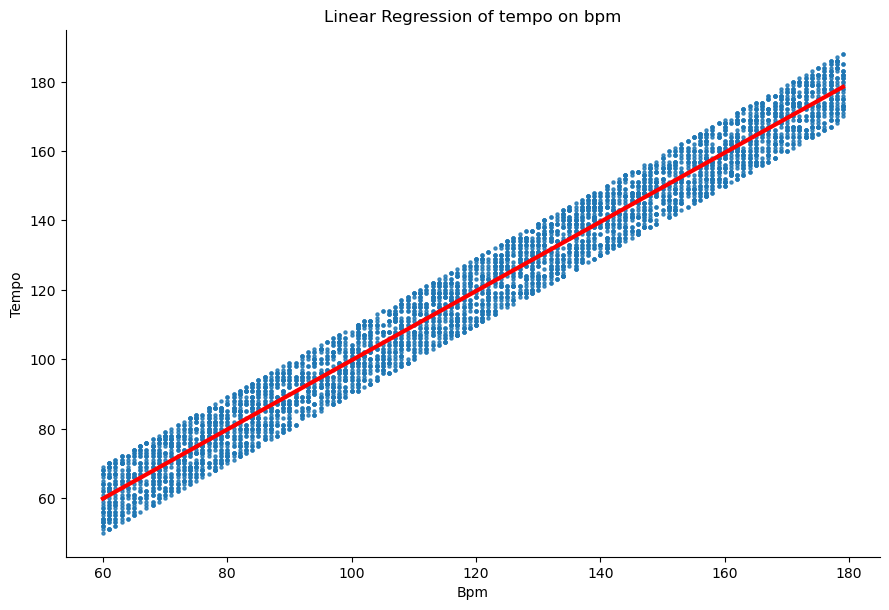

In [7]:
#import seaborn as sns
#import matplotlib.pyplot as plt

def plot_linear_regression(dataset, var1, var2):
    """
    Affiche un graphique de régression linéaire entre deux variables du dataset.
    
    Args:
        dataset (DataFrame): Le DataFrame contenant les données.
        var1 (str): Le nom de la première variable pour l'axe des X.
        var2 (str): Le nom de la deuxième variable pour l'axe des Y.
    """
    # Filtrer les données pour enlever les valeurs manquantes
    dataset_clean = dataset.dropna(subset=[var1, var2])

    # Créer le graphique de régression linéaire
    sns.lmplot(x=var1, y=var2, data=dataset_clean, height=6, aspect=1.5, 
               line_kws={'color': 'red', 'linewidth': 3}, scatter_kws={'s': 5})

    # Ajouter des titres et des labels
    plt.title(f'Linear Regression of {var2} on {var1}')
    plt.xlabel(var1.capitalize())
    plt.ylabel(var2.capitalize())

    # Afficher le graphique
    plt.show()

# Application à notre dataset :
plot_linear_regression(Dataset_Genres_bis, 'bpm', 'tempo')

## Répartition des valeurs prises par chaque variable selon les genres

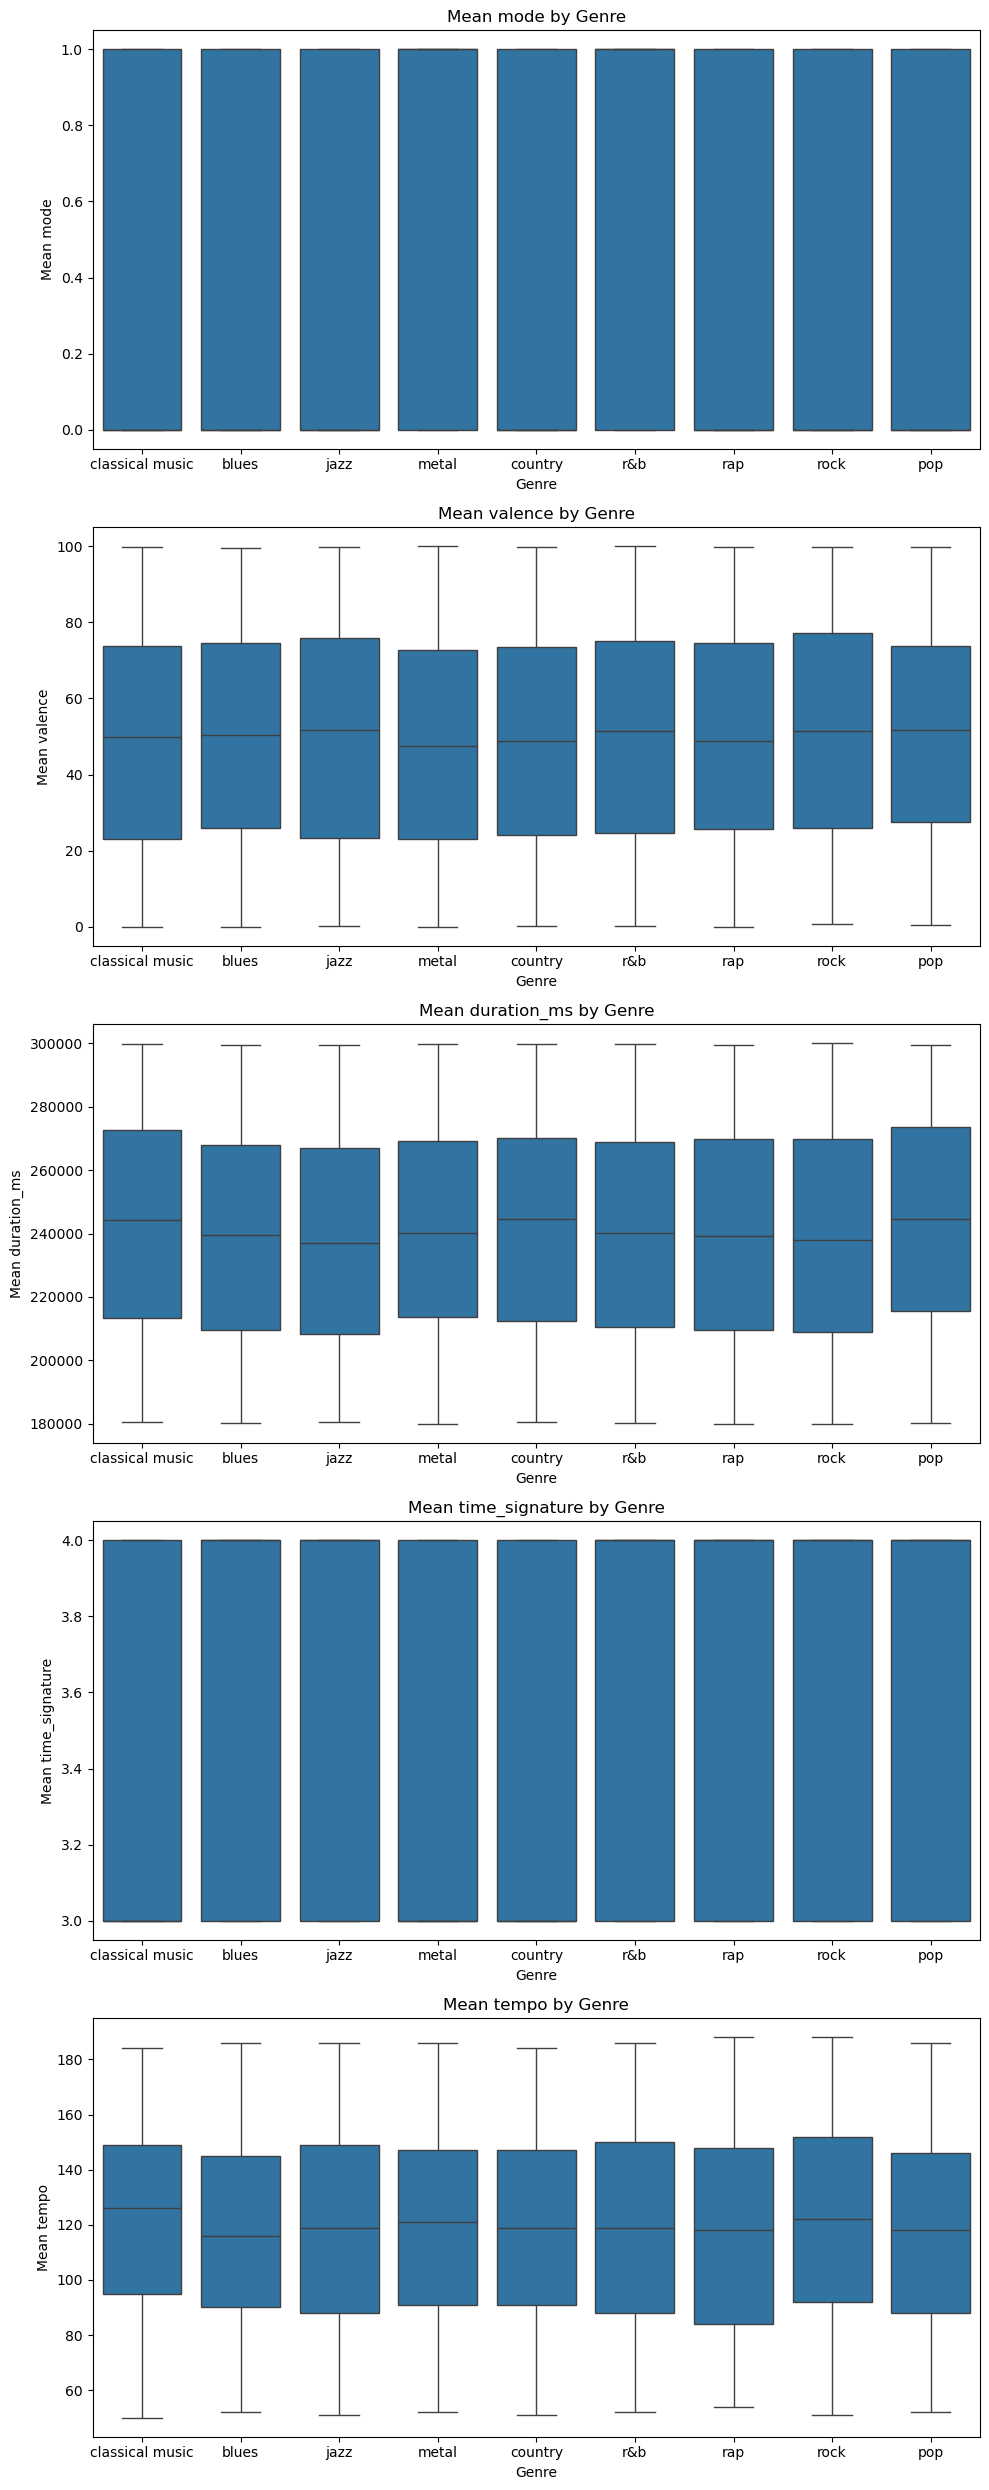

In [8]:
#import seaborn as sns
#import matplotlib.pyplot as plt

def plot_boxplots_by_genre(dataset, columns_to_show):
    """
    Affiche des boxplots pour chaque colonne de `columns_to_show` en fonction du genre.
    
    Args:
        dataset (DataFrame): Le DataFrame contenant les données.
        columns_to_show (list): Liste des colonnes numériques à afficher.
    """
    # Créer les sous-graphiques
    fig, axes = plt.subplots(nrows=len(columns_to_show), ncols=1, figsize=(10, 5 * len(columns_to_show)))

    # Créer un boxplot pour chaque colonne de 'columns_to_show'
    for i, col in enumerate(columns_to_show):
        sns.boxplot(x='genre', y=col, data=dataset, ax=axes[i])
        axes[i].set_title(f'Mean {col} by Genre')
        axes[i].set_xlabel('Genre')
        axes[i].set_ylabel(f'Mean {col}')

    # Ajuster l'espacement entre les graphiques
    plt.tight_layout()
    plt.show()

# Application à notre dataset :
plot_boxplots_by_genre(Dataset_Genres_bis, ['mode', 'valence', 'duration_ms', 'time_signature', 'tempo'])